In [1]:
!pip install -q -U datasets transformers

import numpy as np, pandas as pd, torch, json, pickle
import networkx as nx
from itertools import product
from google.colab import drive

drive.mount("/content/drive")
KG = "/content/drive/MyDrive/ade_kg"
print("GPU:", torch.cuda.is_available())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 133.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 18.3 MB/s eta 0:00:00
Mounted at /content/drive
GPU: True


In [2]:
G2 = pickle.load(open(f"{KG}/kg_linked.pkl", "rb"))
rx_map = json.load(open(f"{KG}/rxcui_map.json"))

n_drug = sum(1 for _, a in G2.nodes(data=True) if a["type"] == "drug")
n_eff  = sum(1 for _, a in G2.nodes(data=True) if a["type"] == "effect")
print(f"graph: {G2.number_of_nodes()} nodes ({n_drug} drugs, {n_eff} effects), {G2.number_of_edges()} edges")

graph: 3927 nodes (944 drugs, 2983 effects), 5076 edges


In [3]:
def query_drug(G, drug_name, min_conf=0.0):
    node = next((n for n, a in G.nodes(data=True)
                 if a["type"] == "drug" and a["label"].lower() == drug_name.lower()), None)
    if node is None:
        return None
    out = []
    for _, eff, d in G.out_edges(node, data=True):
        if d["confidence"] >= min_conf:
            out.append({"effect": G.nodes[eff]["label"], "confidence": d["confidence"],
                        "support": d["support"], "sources": d["sources"]})
    return sorted(out, key=lambda x: -x["support"])

print("methotrexate effects:", len(query_drug(G2, "methotrexate")))   # sanity: should be 157

methotrexate effects: 157


In [4]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

llm_tok = AutoTokenizer.from_pretrained("google/flan-t5-large")
llm_model = AutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-large").to("cuda")

def llm_raw(drug):
    prompt = (f"List the known adverse effects and side effects of the drug {drug}. "
              f"Answer with a comma-separated list of medical conditions.")
    ids = llm_tok(prompt, return_tensors="pt").input_ids.to(llm_model.device)
    out = llm_model.generate(ids, max_new_tokens=64, num_beams=4, do_sample=False)
    return llm_tok.decode(out[0], skip_special_tokens=True)

for name in ["methotrexate", "lithium", "amiodarone", "carbamazepine", "quetiapine"]:
    print(f"{name:>15} -> {llm_raw(name)}")

config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model: reconstructing file:   0%|          |  0.00B /  792kB            

spiece.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

   methotrexate -> Adverse reactions to methotrexate include:
        lithium -> drowsiness, drowsiness, drowsiness, drowsiness, drowsiness, drowsiness, drowsiness, drowsiness, drowsiness, drowsiness, drows
     amiodarone -> drowsiness, drowsiness, drowsiness, drowsiness, drowsiness, drowsiness, drowsiness, drowsiness, drowsiness, drowsiness, drows
  carbamazepine -> drowsiness drowsiness drowsiness drowsiness drowsiness drowsiness drowsiness drowsiness drowsiness drowsiness drowsiness drowsiness drows
     quetiapine -> drowsiness drowsiness drowsiness drowsiness drowsiness drowsiness drowsiness drowsiness drowsiness drowsiness drowsiness drowsiness drows


In [7]:
from groq import Groq
from google.colab import userdata

client = Groq(api_key=userdata.get("GROQ_API_KEY").strip())   # .strip() kills the trailing newline
GROQ_MODEL = "llama-3.1-8b-instant"

def llm_raw(drug):
    prompt = (f"List the known adverse effects and side effects of the drug {drug}. "
              f"Answer with ONLY a comma-separated list of medical conditions, nothing else.")
    r = client.chat.completions.create(
        model=GROQ_MODEL,
        messages=[{"role": "user", "content": prompt}],
        temperature=0, max_tokens=200)
    return r.choices[0].message.content.strip()

for name in ["methotrexate", "lithium", "amiodarone", "carbamazepine", "quetiapine"]:
    print(f"{name} -> {llm_raw(name)}\n")

methotrexate -> Bone marrow suppression, anemia, leukopenia, thrombocytopenia, neutropenia, liver fibrosis, liver cirrhosis, hepatotoxicity, gastrointestinal ulcers, diarrhea, nausea, vomiting, stomatitis, mucositis, alopecia, skin rash, photosensitivity, Stevens-Johnson syndrome, toxic epidermal necrolysis, pulmonary fibrosis, pneumonitis, interstitial lung disease, renal toxicity, acute kidney injury, chronic kidney disease, osteoporosis, osteonecrosis, increased risk of infections, sepsis, reactivation of latent tuberculosis, reactivation of herpes zoster, reactivation of hepatitis B.

lithium -> Thyroid dysfunction, hypothyroidism, hyperthyroidism, weight gain, tremors, muscle weakness, fatigue, cognitive impairment, memory loss, confusion, ataxia, dysarthria, nephrotoxicity, renal impairment, polyuria, polydipsia, hypokalemia, hypernatremia, hypomagnesemia, hypocalcemia, hypophosphatemia, leukocytosis, leukopenia, thrombocytopenia, anemia, alopecia, acne, dermatitis, psoriasis, St

In [8]:
import re

def parse_effects(text):
    parts = re.split(r"[,\n;]", text.lower())
    return {p.strip(" .") for p in parts if p.strip(" .")}

# eval set: drugs in the KG with at least a few gold effects, so precision is meaningful
drug_nodes = [(n, a["label"]) for n, a in G2.nodes(data=True) if a["type"] == "drug"]
eval_drugs = []
for node, lbl in drug_nodes:
    effs = query_drug(G2, lbl)
    if effs and len(effs) >= 3:
        eval_drugs.append(lbl)
eval_drugs = sorted(eval_drugs)[:40]          # cap at 40 to keep API calls modest
print(f"evaluating on {len(eval_drugs)} drugs")

rows = []
for lbl in eval_drugs:
    kg = query_drug(G2, lbl)
    kg_effs = {e["effect"].lower() for e in kg}
    gold = kg_effs                                   # KG is built from the gold relations, so its effects ARE the corpus gold
    llm_effs = parse_effects(llm_raw(lbl))
    rows.append({
        "drug": lbl,
        "kg_n": len(kg_effs),
        "kg_attributable": len(kg_effs),             # every KG effect has a source sentence
        "llm_n": len(llm_effs),
        "llm_attributable": 0,                        # the LLM cites nothing
        "llm_in_corpus": len(llm_effs & gold),        # overlap with corpus — NOT a correctness measure
    })

ev = pd.DataFrame(rows)
print(ev.head(10).to_string(index=False))

evaluating on 40 drugs
                                           drug  kg_n  kg_attributable  llm_n  llm_attributable  llm_in_corpus
                           13-cis-retinoic acid    13               13     48                 0              0
                        2-chloro-deoxyadenosine     9                9     40                 0              1
                         2-propylpentanoic acid    19               19     24                 0              0
4% ethyl nitrite ch3ch2ono in 70% ethyl alcohol     4                4      2                 0              0
                          5-aminosalicylic acid    16               16     35                 0              1
                               5-fluorocytosine     6                6     22                 0              2
                                 5-fluorouracil    45               45     32                 0              4
                                  6-thioguanine     4                4     24            

In [9]:
# pick the drugs with the most gold effects — the well-attested, real-name ones where the comparison is fair
ranked = sorted(((lbl, len(query_drug(G2, lbl))) for _, lbl in
                 [(n, a["label"]) for n, a in G2.nodes(data=True) if a["type"] == "drug"]),
                key=lambda x: -x[1])
eval_drugs = [lbl for lbl, k in ranked if k >= 3][:40]
print("eval drugs:", eval_drugs[:12], "...\n")

rows = []
for lbl in eval_drugs:
    kg_effs = {e["effect"].lower() for e in query_drug(G2, lbl)}
    llm_effs = parse_effects(llm_raw(lbl))
    rows.append({
        "drug": lbl,
        "kg_claims": len(kg_effs),
        "kg_verifiable": len(kg_effs),        # each carries a source sentence
        "llm_claims": len(llm_effs),
        "llm_verifiable": 0,                   # no sources — nothing to check
    })

ev = pd.DataFrame(rows)
print(ev.head(12).to_string(index=False))

tot_kg, tot_llm = ev.kg_claims.sum(), ev.llm_claims.sum()
print(f"\nacross {len(ev)} drugs:")
print(f"  KG:  {tot_kg} claims, {tot_kg} verifiable (100%)")
print(f"  LLM: {tot_llm} claims, 0 verifiable (0%)")
print(f"  the LLM made {tot_llm} confident assertions, none traceable to a source")

eval drugs: ['methotrexate', 'lithium', 'carbamazepine', 'cis-platinum', 'amiodarone', 'cyclosporine a', '5-fluorouracil', 'diphenylhydantoin', 'infliximab', 'cyclophosphamide', 'clozapine', 'salazosulfapyridine'] ...

               drug  kg_claims  kg_verifiable  llm_claims  llm_verifiable
       methotrexate        157            157          32               0
            lithium         69             69          45               0
      carbamazepine         59             59          47               0
       cis-platinum         48             48          48               0
         amiodarone         48             48          37               0
     cyclosporine a         46             46          45               0
     5-fluorouracil         45             45          32               0
  diphenylhydantoin         44             44          47               0
         infliximab         41             41          38               0
   cyclophosphamide         40           

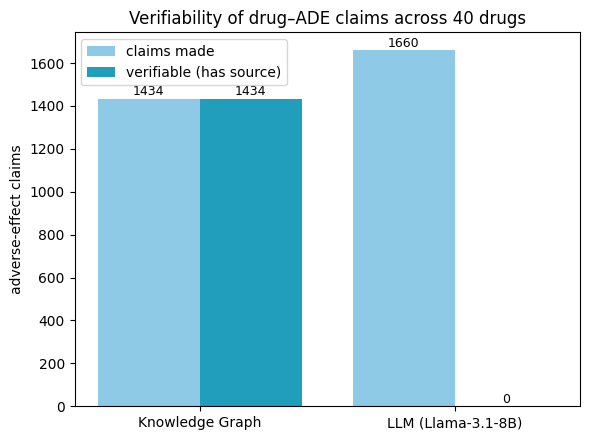

saved figure + results table


In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4.5))
x = [0, 1]
ax.bar([p - 0.2 for p in x], [tot_kg, tot_llm], 0.4, label="claims made", color="#8ecae6")
ax.bar([p + 0.2 for p in x], [tot_kg, 0], 0.4, label="verifiable (has source)", color="#219ebc")
ax.set_xticks(x); ax.set_xticklabels(["Knowledge Graph", "LLM (Llama-3.1-8B)"])
ax.set_ylabel("adverse-effect claims"); ax.legend()
ax.set_title(f"Verifiability of drug–ADE claims across {len(ev)} drugs")
for p, c, v in [(0, tot_kg, tot_kg), (1, tot_llm, 0)]:
    ax.text(p - 0.2, c + 15, str(c), ha="center", fontsize=9)
    ax.text(p + 0.2, v + 15, str(v), ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(f"{KG}/verifiability.png", dpi=150, bbox_inches="tight")
plt.show()

ev.to_csv(f"{KG}/grounding_results.csv", index=False)
print("saved figure + results table")